**Step 1a**

/tmp/ipython-input-1121635320.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER_SYMBOL, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed



 BASIC INFORMATION 
Ticker: AMZN
Periods: 1378 observations

 DISTRIBUTION STATS 
Mean (daily log return): 0.000621
Std (volatility):       0.022766
Skewness:               -0.0730
Excess Kurtosis:        4.1775
Jarque-Bera p-value:    0.0000

 ADF STATIONARITY TEST 
ADF Statistic: -38.4712
p-value:       0.0000
Reject Null (stationary) if p < 0.05



<Figure size 800x400 with 0 Axes>

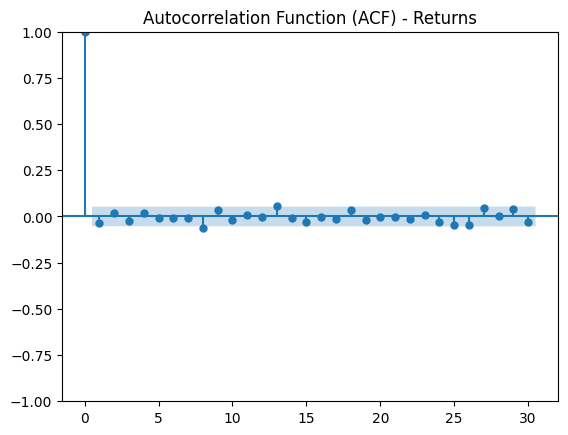

<Figure size 800x400 with 0 Axes>

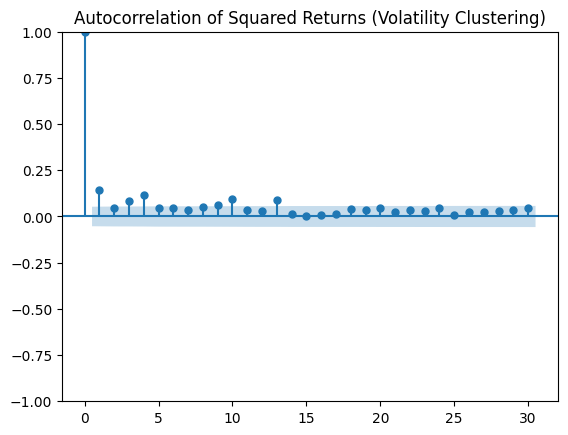

 FIVE-NUMBER SUMMARY 
count    1378.000000
mean        0.000621
std         0.022766
min        -0.151398
1%         -0.057652
5%         -0.034088
25%        -0.011290
50%         0.000646
75%         0.012944
95%         0.035305
99%         0.061576
max         0.126949
Name: AMZN, dtype: float64


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import skew, kurtosis

# -----------------------
# Parameters
# -----------------------
TICKER_SYMBOL = "AMZN"
START_DATE = "2020-01-01"
END_DATE = "2025-06-30"

# -----------------------
# 1. Download price data
# -----------------------
data = yf.download(TICKER_SYMBOL, start=START_DATE, end=END_DATE)

# Ensure Close is a Series, not a DataFrame
prices = data["Close"].squeeze()   # <--- FIX HERE

# -----------------------
# 2. Compute log returns
# -----------------------
returns = np.log(prices / prices.shift(1)).dropna()

print("\n====================")
print(" BASIC INFORMATION ")
print("====================")
print(f"Ticker: {TICKER_SYMBOL}")
print(f"Periods: {len(returns)} observations\n")

# -----------------------
# 3. Summary statistics
# -----------------------
mean_ret = float(returns.mean())
std_ret = float(returns.std())
skew_ret = float(skew(returns))
kurt_ret = float(kurtosis(returns))  # excess kurtosis

jb_stat, jb_p, _, _ = jarque_bera(returns)

print("====================")
print(" DISTRIBUTION STATS ")
print("====================")
print(f"Mean (daily log return): {mean_ret:.6f}")
print(f"Std (volatility):       {std_ret:.6f}")
print(f"Skewness:               {skew_ret:.4f}")
print(f"Excess Kurtosis:        {kurt_ret:.4f}")
print(f"Jarque-Bera p-value:    {jb_p:.4f}\n")

# -----------------------
# 4. ADF unit root test
# -----------------------
adf_stat, adf_p, _, _, _, _ = adfuller(returns)

print("====================")
print(" ADF STATIONARITY TEST ")
print("====================")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value:       {adf_p:.4f}")
print("Reject Null (stationary) if p < 0.05\n")

# -----------------------
# 5. Autocorrelation
# -----------------------
plt.figure(figsize=(8,4))
plot_acf(returns, lags=30)
plt.title("Autocorrelation Function (ACF) - Returns")
plt.show()

plt.figure(figsize=(8,4))
plot_acf(returns**2, lags=30)
plt.title("Autocorrelation of Squared Returns (Volatility Clustering)")
plt.show()

# -----------------------
# 6. Five-number summary
# -----------------------
print("====================")
print(" FIVE-NUMBER SUMMARY ")
print("====================")
print(returns.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))



Step 1b)

In [2]:
# Run in terminal or notebook cell with `!` prefix
!pip install yfinance statsmodels numpy pandas matplotlib seaborn scikit-learn tensorflow pyts fracdiff


ERROR: Ignored the following versions that require a different python version: 0.9.0 Requires-Python >=3.7.12,<3.10
ERROR: Could not find a version that satisfies the requirement fracdiff (from versions: none)
ERROR: No matching distribution found for fracdiff


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
TICKER = "BTC-USD"
MAX_OBS = 2000

# fetch
df = yf.download(TICKER, period="max", progress=False)  # or specify start/end dates
df = df[["Close"]].dropna().rename(columns={"Close":"price"})
df = df.tail(MAX_OBS).copy()
df.index = pd.to_datetime(df.index)
df.head()


/tmp/ipython-input-1984510139.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, period="max", progress=False)  # or specify start/end dates


Price,price
Ticker,BTC-USD
Date,
2020-06-05,9665.533203
2020-06-06,9653.679688
2020-06-07,9758.852539
2020-06-08,9771.489258
2020-06-09,9795.700195


ADF statistic: -46.07273539451245
p-value: 0.0
Critical value (1%): -3.4336
Critical value (5%): -2.8630
Critical value (10%): -2.5675
count    1999.000000
mean        0.001105
std         0.030401
min        -0.174053
25%        -0.012836
50%         0.000449
75%         0.015007
max         0.171821
Name: r1, dtype: float64


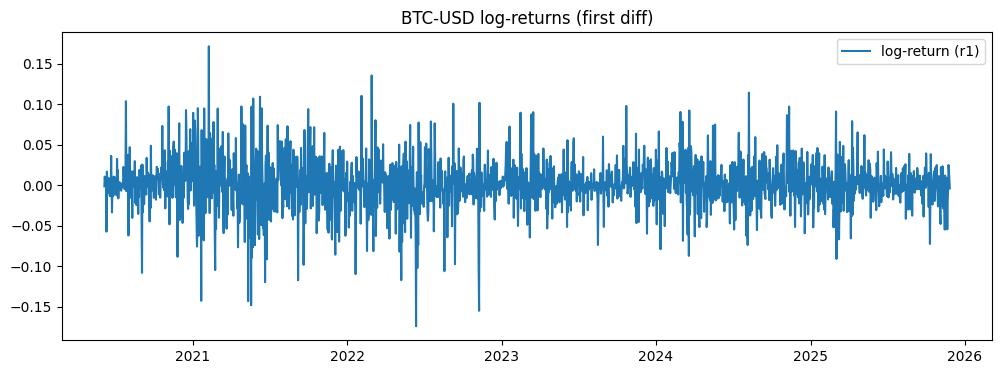

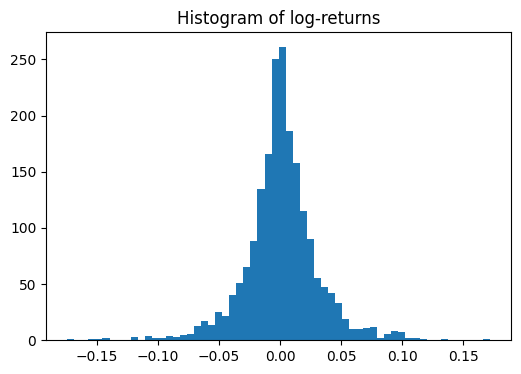

In [4]:
from statsmodels.tsa.stattools import adfuller

# log price and first difference (returns)
df["log_price"] = np.log(df["price"])
df["r1"] = df["log_price"].diff().dropna()

# drop initial NaN
series = df["r1"].dropna()

# ADF test
adf_res = adfuller(series, autolag="AIC")
print("ADF statistic:", adf_res[0])
print("p-value:", adf_res[1])
for k,v in adf_res[4].items():
    print("Critical value ({}): {:.4f}".format(k, v))

# Quick summary stats and plots
print(series.describe())

plt.figure(figsize=(12,4))
plt.plot(series.index, series, label="log-return (r1)")
plt.title("BTC-USD log-returns (first diff)")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(series, bins=60)
plt.title("Histogram of log-returns")
plt.show()


**Step 1(c)**

In [5]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
borismarjanovic_price_volume_data_for_all_us_stocks_etfs_path = kagglehub.dataset_download('borismarjanovic/price-volume-data-for-all-us-stocks-etfs')

print('Data source import complete.')


Using Colab cache for faster access to the 'price-volume-data-for-all-us-stocks-etfs' dataset.
Data source import complete.


## Getting started

In [6]:

import numpy as np
import pandas as pd
import gc
import os
import random
import copy
import matplotlib.pyplot as plt
import pandas
import statsmodels
from datetime import datetime
from statsmodels.tsa.stattools import adfuller

We'll analyze the closing price of AMZN stocks

/tmp/ipython-input-1763827541.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/Data/Stocks/amzn.us.txt',parse_dates=['Date'],index_col=['Date'],date_parser=dateparse)


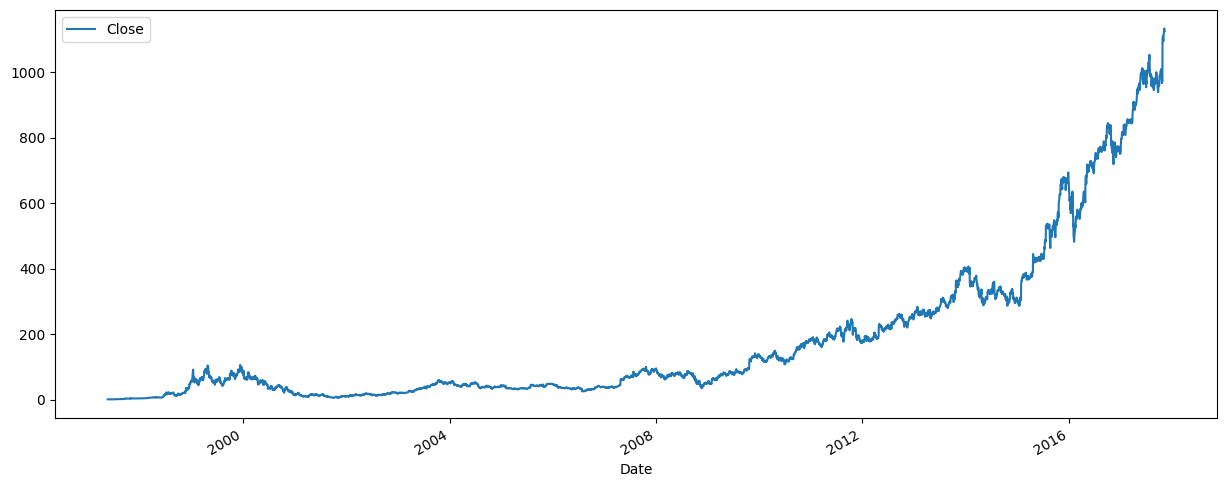

In [7]:
dateparse = lambda d: datetime.strptime(d, '%Y-%m-%d')
df=pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/Data/Stocks/amzn.us.txt',parse_dates=['Date'],index_col=['Date'],date_parser=dateparse)
df=df.drop(columns=['Open','High','Low','Volume','OpenInt'])
df.plot(figsize=(15,6))
plt.show()

Usually univariate time series analysis is done on a stationary series, so first off we'll check for stationarity using the ADF test

In [8]:
adftest=adfuller(df['Close'])
print('ADF Statistic: %f' % adftest[0])
print('ADF p-value: %f' % adftest[1])

ADF Statistic: 4.573103
ADF p-value: 1.000000


We cannot reject the null hypothesis of non-stationarity. A popular way to try and circumvent this is to use the logarithm of the original series, so lets see how that works out.

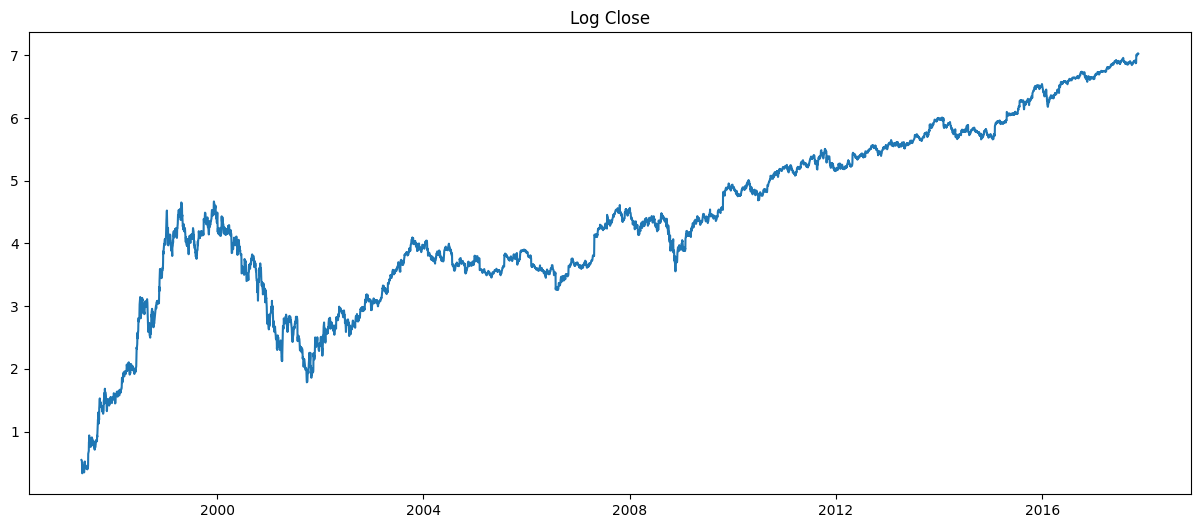

In [9]:
df_log=pd.DataFrame(np.log(df['Close']),index=df.index)
plt.figure(figsize=(15,6))
plt.plot(df_log)
plt.title('Log Close')
plt.show()

In [10]:
adftest=adfuller(df_log['Close'])
print('ADF Statistic: %f' % adftest[0])
print('ADF p-value: %f' % adftest[1])

ADF Statistic: -1.946347
ADF p-value: 0.310582


## Traditional Differencing

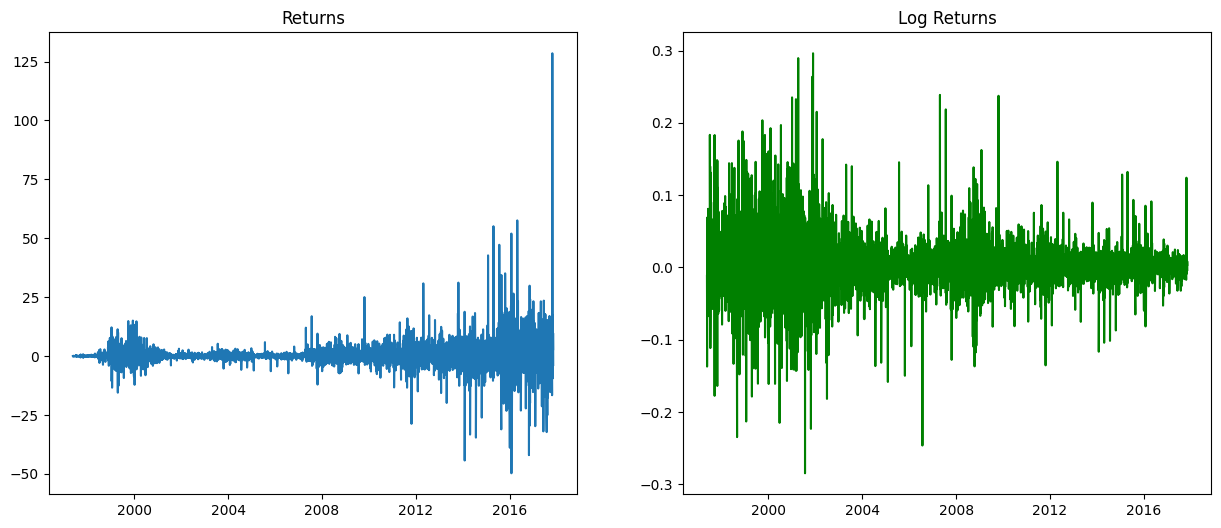

In [11]:
df['Returns']=df['Close']-df['Close'].shift(1)
df_log['Log_Returns']=df_log['Close']-df_log['Close'].shift(1)
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(df['Returns'])
plt.title('Returns')
plt.subplot(1,2,2)
plt.plot(df_log['Log_Returns'],'g-')
plt.title('Log Returns')
plt.show()

ADF test

In [12]:
adftest_ret=adfuller(df['Returns'].dropna())
print('Returns ADF Statistic: %f' % adftest_ret[0])
print('Returns ADF p-value: %f' % adftest_ret[1])
adftest_lret=adfuller(df_log['Log_Returns'].dropna())
print('Log-Returns ADF Statistic: %f' % adftest_lret[0])
print('Log-Returns ADF p-value: %f' % adftest_lret[1])

Returns ADF Statistic: -10.979058
Returns ADF p-value: 0.000000
Log-Returns ADF Statistic: -12.174476
Log-Returns ADF p-value: 0.000000


## Fractional Differencing

In [13]:
def getWeights(d,lags):
    # return the weights from the series expansion of the differencing operator
    # for real orders d and up to lags coefficients
    w=[1]
    for k in range(1,lags):
        w.append(-w[-1]*((d-k+1))/k)
    w=np.array(w).reshape(-1,1)
    return w
def plotWeights(dRange, lags, numberPlots):
    weights=pd.DataFrame(np.zeros((lags, numberPlots)))
    interval=np.linspace(dRange[0],dRange[1],numberPlots)
    for i, diff_order in enumerate(interval):
        weights[i]=getWeights(diff_order,lags)
    weights.columns = [round(x,2) for x in interval]
    fig=weights.plot(figsize=(15,6))
    plt.legend(title='Order of differencing')
    plt.title('Lag coefficients for various orders of differencing')
    plt.xlabel('lag coefficients')
    #plt.grid(False)
    plt.show()
def ts_differencing(series, order, lag_cutoff):
    # return the time series resulting from (fractional) differencing
    # for real orders order up to lag_cutoff coefficients

    weights=getWeights(order, lag_cutoff)
    res=0
    for k in range(lag_cutoff):
        res += weights[k]*series.shift(k).fillna(0)
    return res[lag_cutoff:]

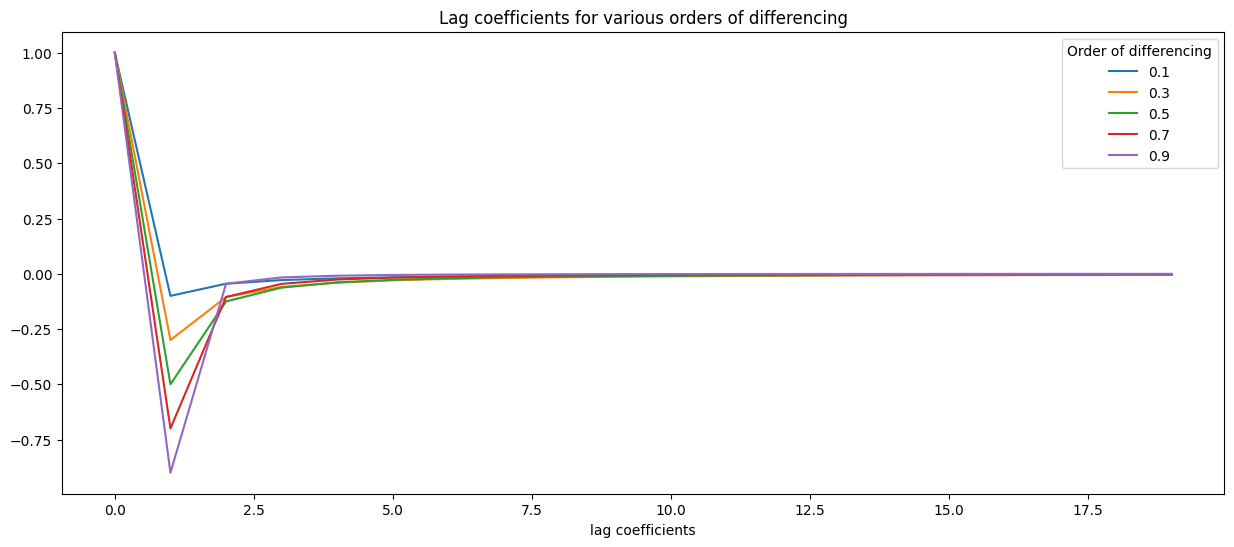

In [14]:
plotWeights([0.1,0.9],20,5)

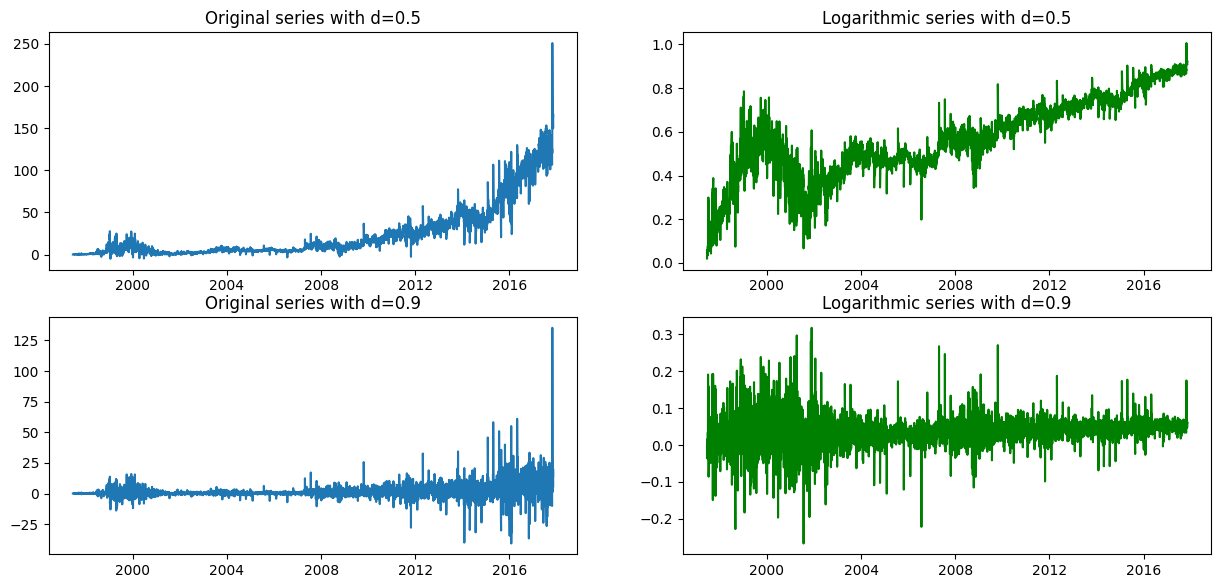

In [15]:
differences=[0.5,0.9]
fig, axs = plt.subplots(len(differences),2,figsize=(15,6))
for i in range(0,len(differences)):
    axs[i,0].plot(ts_differencing(df['Close'],differences[i],20))
    axs[i,0].set_title('Original series with d='+str(differences[i]))
    axs[i,1].plot(ts_differencing(df_log['Close'],differences[i],20),'g-')
    axs[i,1].set_title('Logarithmic series with d='+str(differences[i]))
    plt.subplots_adjust(bottom=0.01) #increasing space between plots for aestethics

In [16]:
def cutoff_find(order,cutoff,start_lags): #order is our dearest d, cutoff is 1e-5 for us, and start lags is an initial amount of lags in which the loop will start, this can be set to high values in order to speed up the algo
    val=np.inf
    lags=start_lags
    while abs(val)>cutoff:
        w=getWeights(order, lags)
        val=w[len(w)-1]
        lags+=1
    return lags

In [17]:
def ts_differencing_tau(series, order, tau):
    # return the time series resulting from (fractional) differencing
    lag_cutoff=(cutoff_find(order,tau,1)) #finding lag cutoff with tau
    weights=getWeights(order, lag_cutoff)
    res=0
    for k in range(lag_cutoff):
        res += weights[k]*series.shift(k).fillna(0)
    return res[lag_cutoff:]

In [18]:
#this part takes about 20 minutes to compute
possible_d=np.divide(range(1,100),100)
tau=1e-4
original_adf_stat_holder=[None]*len(possible_d)
log_adf_stat_holder=[None]*len(possible_d)

for i in range(len(possible_d)):
    original_adf_stat_holder[i]=adfuller(ts_differencing_tau(df['Close'],possible_d[i],tau))[1]
    log_adf_stat_holder[i]=adfuller(ts_differencing_tau(df_log['Close'],possible_d[i],tau))[1]

Text(0.5, 1.0, 'ADF P-value by differencing order in the logarithmic series')

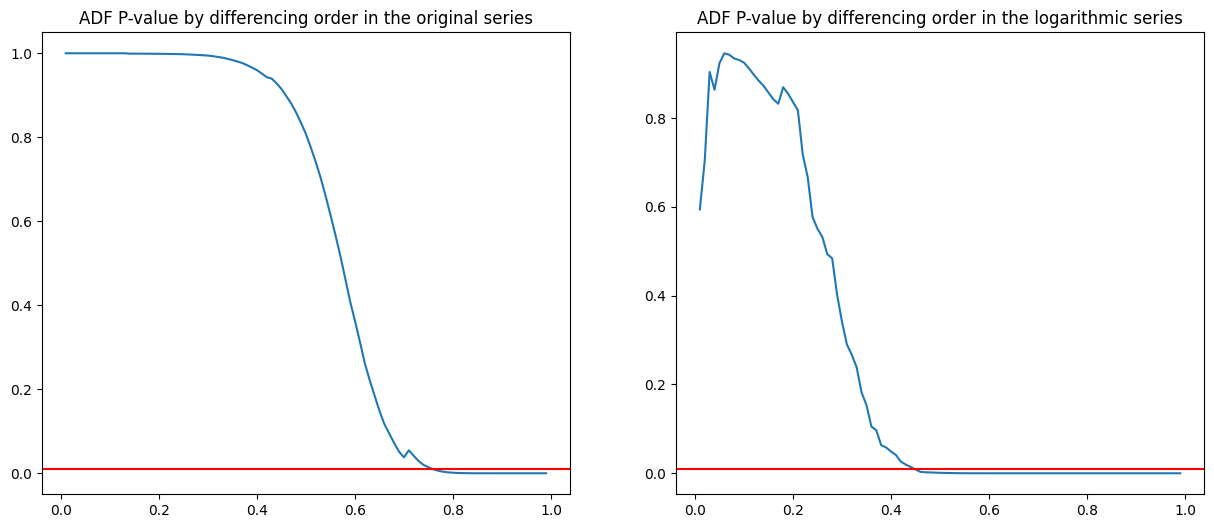

In [19]:
#now the plots of the ADF p-values
fig, axs = plt.subplots(1,2,figsize=(15,6))
axs[0].plot(possible_d,original_adf_stat_holder)
axs[0].axhline(y=0.01,color='r')
axs[0].set_title('ADF P-value by differencing order in the original series')
axs[1].plot(possible_d,log_adf_stat_holder)
axs[1].axhline(y=0.01,color='r')
axs[1].set_title('ADF P-value by differencing order in the logarithmic series')

**Step 2(a)**

/tmp/ipython-input-3628711203.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START, end=END)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0997 - val_loss: 0.0013
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 4.8629e-04
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.6654e-04 - val_loss: 5.2187e-04
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0060e-04 - val_loss: 3.8268e-04
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0057e-04 - val_loss: 3.7338e-04
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3151e-04 - val_loss: 4.8492e-04
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8164e-04 - val_loss: 4.4446e-04
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4942e-04 - val_loss: 4.3335e-04
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2897e-04 - val_loss: 3.4741e-04
Epoch 10/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6186e-04 - val_loss: 3.7370e-04
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.5690e-04 - val_loss: 3.6329e-0

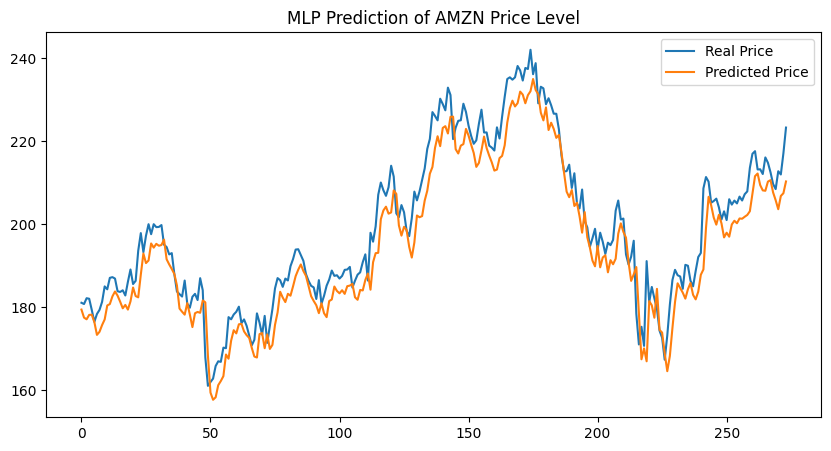

In [20]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ------------------------------
# 1. Download time series data
# ------------------------------
TICKER = "AMZN"
START = "2020-01-01"
END = "2025-06-30"

data = yf.download(TICKER, start=START, end=END)
prices = data["Close"].dropna()

# Convert to numpy
prices = prices.values.reshape(-1, 1)

# ------------------------------
# 2. Normalize data
# ------------------------------
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices)

# ------------------------------
# 3. Build supervised dataset
# past N days → next day
# ------------------------------
N_LAGS = 10  # number of past days used as input

def create_dataset(series, n_lags):
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i-n_lags:i, 0])
        y.append(series[i, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_prices, N_LAGS)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ------------------------------
# 4. Build MLP model
# ------------------------------
model = Sequential()
model.add(Dense(64, activation="relu", input_shape=(N_LAGS,)))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))  # predict level

model.compile(optimizer="adam", loss="mse")

model.summary()

# ------------------------------
# 5. Train model
# ------------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# ------------------------------
# 6. Make predictions
# ------------------------------
y_pred = model.predict(X_test)

# Invert scaling
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_real = scaler.inverse_transform(y_pred)

# ------------------------------
# 7. Plot prediction vs actual
# ------------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test_real, label="Real Price")
plt.plot(y_pred_real, label="Predicted Price")
plt.title("MLP Prediction of AMZN Price Level")
plt.legend()
plt.show()


step 2b)

In [21]:
!pip install pyts


  Using cached pyts-0.13.0-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.6 MB/s eta 0:00:00


In [22]:
import numpy as np
import pandas as pd

def get_fracdiff_weights(d, size):
    """Generate fractional differencing weights."""
    w = [1.0]
    for k in range(1, size):
        w.append(-w[-1] * (d - k + 1) / k)
    return np.array(w)

def fracdiff(series, d, thresh=1e-5):
    """
    Fractionally difference a time series.
    Works even when the 'fracdiff' package cannot be installed.
    """
    series = pd.Series(series)
    T = len(series)
    weights = get_fracdiff_weights(d, T)

    # Remove tiny weights to reduce computation
    weights = weights[np.abs(weights) > thresh]

    fd = np.zeros(T)
    for t in range(len(weights), T):
        fd[t] = np.sum(weights * series.values[t-len(weights)+1:t+1])
    return pd.Series(fd, index=series.index)


/tmp/ipython-input-1270011884.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", period="max", progress=False)


ADF Statistic: -46.07291460316586
p-value: 0.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
44/44 - 5s - 108ms/step - loss: 0.1055 - mae: 0.2319 - val_loss: 0.0117 - val_mae: 0.0807
Epoch 2/200
44/44 - 1s - 17ms/step - loss: 0.0401 - mae: 0.1467 - val_loss: 0.0059 - val_mae: 0.0590
Epoch 3/200
44/44 - 1s - 13ms/step - loss: 0.0243 - mae: 0.1141 - val_loss: 0.0040 - val_mae: 0.0472
Epoch 4/200
44/44 - 1s - 14ms/step - loss: 0.0149 - mae: 0.0892 - val_loss: 0.0027 - val_mae: 0.0402
Epoch 5/200
44/44 - 1s - 13ms/step - loss: 0.0103 - mae: 0.0748 - val_loss: 0.0020 - val_mae: 0.0341
Epoch 6/200
44/44 - 0s - 8ms/step - loss: 0.0069 - mae: 0.0609 - val_loss: 0.0015 - val_mae: 0.0299
Epoch 7/200
44/44 - 1s - 13ms/step - loss: 0.0057 - mae: 0.0536 - val_loss: 0.0013 - val_mae: 0.0277
Epoch 8/200
44/44 - 1s - 17ms/step - loss: 0.0052 - mae: 0.0491 - val_loss: 0.0011 - val_mae: 0.0249
Epoch 9/200
44/44 - 1s - 13ms/step - loss: 0.0033 - mae: 0.0423 - val_loss: 9.4556e-04 - val_mae: 0.0232
Epoch 10/200
44/44 - 1s - 13ms/step - loss: 0.0033 - mae: 0.0414 - val_loss: 8.6533e-04

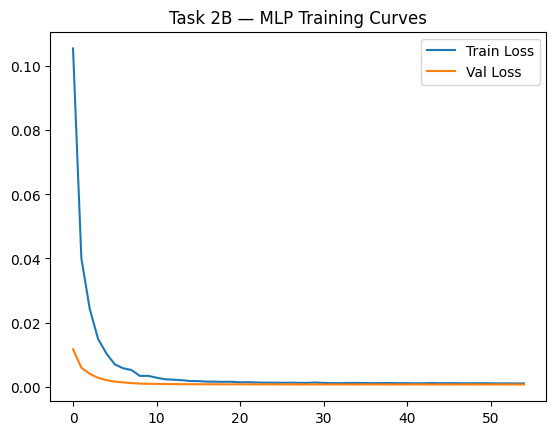

Task 2B — Test MSE: 0.0005065510049462318
Task 2B — Test MAE: 0.016195839270949364
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


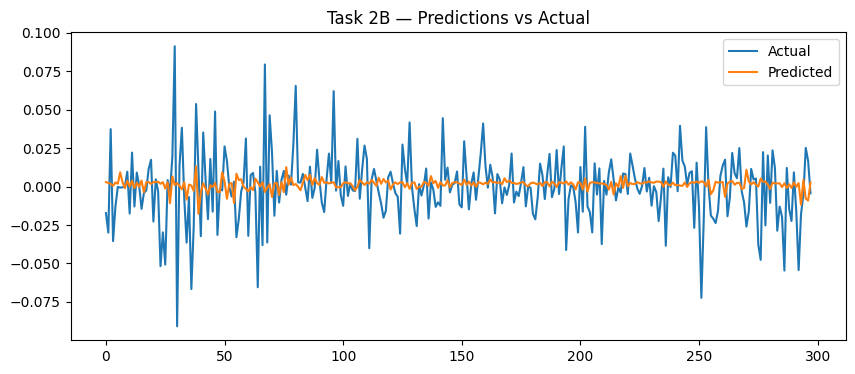

In [23]:
# ============================================================
# TASK 2B — MLP USING STATIONARY SERIES
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ------------------------------------------------------------
# 1. LOAD BTC-USD AND CREATE STATIONARY SERIES (LOG RETURNS)
# ------------------------------------------------------------
df = yf.download("BTC-USD", period="max", progress=False)
df = df[["Close"]].dropna().tail(2000)
df.rename(columns={"Close": "price"}, inplace=True)

df["log_price"] = np.log(df["price"])
df["r1"] = df["log_price"].diff()
stationary = df["r1"].dropna()

# ADF Test
adf = adfuller(stationary)
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

# ------------------------------------------------------------
# 2. CREATE LAG FEATURES
# ------------------------------------------------------------
def create_lags(series, lags=20):
    df_lag = pd.DataFrame()
    for i in range(1, lags + 1):
        df_lag[f"lag_{i}"] = series.shift(i)
    df_lag["y"] = series
    df_lag = df_lag.dropna()
    return df_lag.drop(columns=["y"]).values, df_lag["y"].values

X, y = create_lags(stationary, 20)

# Split: 70/15/15
train_size = int(0.70 * len(X))
val_size   = int(0.15 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val     = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test   = X[train_size+val_size:], y[train_size+val_size:]

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ------------------------------------------------------------
# 3. BUILD MLP MODEL
# ------------------------------------------------------------
def build_mlp(input_dim):
    model = models.Sequential([
        layers.Dense(128, activation="relu", input_shape=(input_dim,)),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse", metrics=["mae"])
    return model

mlp = build_mlp(X_train.shape[1])

early_stop = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True
)

# ------------------------------------------------------------
# 4. TRAIN MODEL
# ------------------------------------------------------------
history = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

# Training plot
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Task 2B — MLP Training Curves")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 5. EVALUATE MODEL
# ------------------------------------------------------------
test_mse, test_mae = mlp.evaluate(X_test, y_test, verbose=0)
print("Task 2B — Test MSE:", test_mse)
print("Task 2B — Test MAE:", test_mae)

# Predictions plot
y_pred = mlp.predict(X_test).flatten()

plt.figure(figsize=(10,4))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Task 2B — Predictions vs Actual")
plt.legend()
plt.show()


**Step 2(c)**

In [27]:
import pandas as pd
import numpy as np

def fracdiff(series, d, thresh=1e-4):
    w = [1.]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thresh:
            break
        w.append(w_k)
        k += 1

    w = np.array(w[::-1])
    out = pd.Series(index=series.index, dtype=float)

    for i in range(len(w), len(series)):
        out.iloc[i] = np.dot(w, series.iloc[i-len(w):i])

    return out.dropna()

In [28]:
fd_series = fracdiff(price, d=0.40)
print(fd_series.head())
print(fd_series.describe())

Date
2018-09-06     9.301075
2018-09-07     7.998259
2018-09-10     8.432976
2018-09-11     8.073488
2018-09-12    10.830743
dtype: float64
count    976.000000
mean       9.564283
std        5.259571
min      -12.646059
25%        6.195872
50%        9.044640
75%       12.926076
max       26.067863
dtype: float64


Supervised shape: (956, 24)
Sizes -> Train: (668, 23) Val: (144, 23) Test: (144, 23)
Epoch 1/200
21/21 - 2s - 72ms/step - loss: 0.6583 - mae: 0.6133 - val_loss: 0.4264 - val_mae: 0.4873
Epoch 2/200
21/21 - 0s - 6ms/step - loss: 0.4327 - mae: 0.4745 - val_loss: 0.3503 - val_mae: 0.4338
Epoch 3/200
21/21 - 0s - 6ms/step - loss: 0.3892 - mae: 0.4511 - val_loss: 0.3555 - val_mae: 0.4357
Epoch 4/200
21/21 - 0s - 10ms/step - loss: 0.3436 - mae: 0.4291 - val_loss: 0.3691 - val_mae: 0.4462
Epoch 5/200
21/21 - 0s - 11ms/step - loss: 0.3105 - mae: 0.4031 - val_loss: 0.3686 - val_mae: 0.4383
Epoch 6/200
21/21 - 0s - 6ms/step - loss: 0.3333 - mae: 0.4143 - val_loss: 0.3657 - val_mae: 0.4382
Epoch 7/200
21/21 - 0s - 6ms/step - loss: 0.3056 - mae: 0.3911 - val_loss: 0.3578 - val_mae: 0.4314
Epoch 8/200
21/21 - 0s - 6ms/step - loss: 0.2921 - mae: 0.3853 - val_loss: 0.3622 - val_mae: 0.4334
Epoch 9/200
21/21 - 0s - 6ms/step - loss: 0.2826 - mae: 0.3825 - val_loss: 0.3621 - val_mae: 0.4321
Epoch 10/200

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Binary Classifier -> Acc: 0.806, AUC: 0.794, Prec: 0.867, Rec: 0.897, F1: 0.881
Epoch 1/200
21/21 - 3s - 155ms/step - accuracy: 0.7290 - loss: 0.6505 - val_accuracy: 0.9861 - val_loss: 0.1867
Epoch 2/200
21/21 - 1s - 34ms/step - accuracy: 0.7650 - loss: 0.4565 - val_accuracy: 0.9861 - val_loss: 0.1480
Epoch 3/200
21/21 - 0s - 6ms/step - accuracy: 0.8219 - loss: 0.4071 - val_accuracy: 0.9861 - val_loss: 0.1346
Epoch 4/200
21/21 - 0s - 7ms/step - accuracy: 0.8084 - loss: 0.4113 - val_accuracy: 0.9861 - val_loss: 0.1284
Epoch 5/200
21/21 - 0s - 6ms/step - accuracy: 0.8234 - loss: 0.4043 - val_accuracy: 0.9861 - val_loss: 0.1241
Epoch 6/200
21/21 - 0s - 6ms/step - accuracy: 0.8503 - loss: 0.3643 - val_accuracy: 0.9861 - val_loss: 0.1210
Epoch 7/200
21/21 - 0s - 7ms/step - accuracy: 0.8353 - loss: 0.3659 - val_accuracy: 0.9861 - val_loss: 0.1182
Epoch 8/200
21/21 - 0s - 6ms/step - accuracy: 0.8383 - loss: 0.3578 - val_accuracy: 0.9861 - val_loss: 0.1177

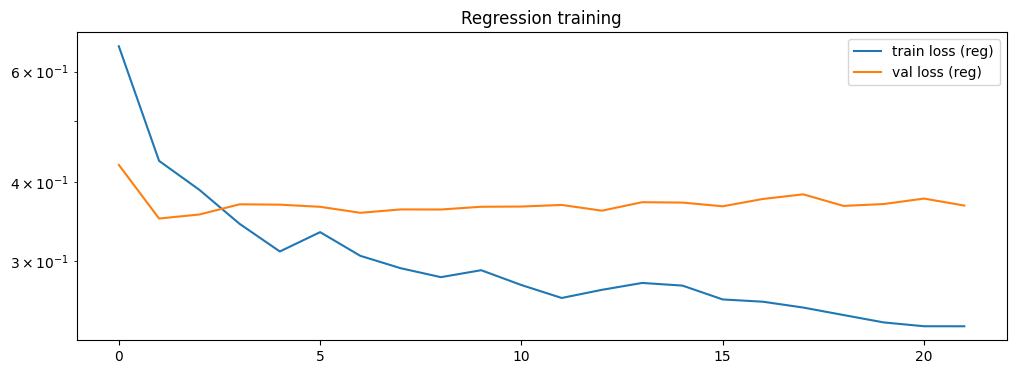

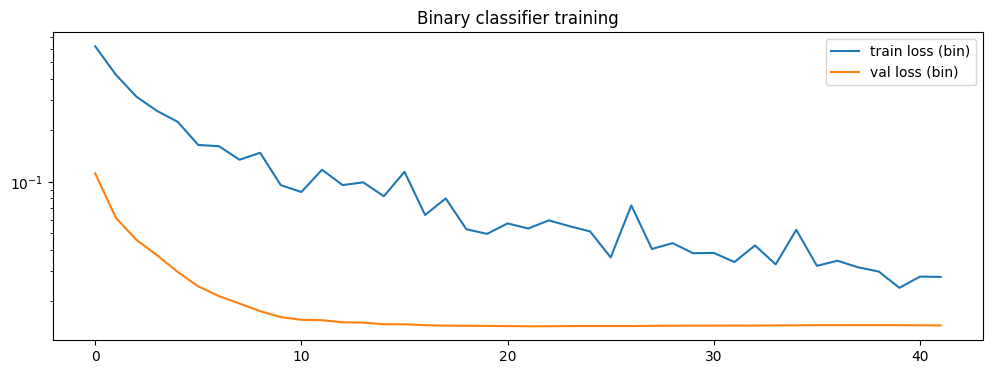

In [29]:
# Requirements: numpy, pandas, sklearn, tensorflow, matplotlib, statsmodels
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, roc_auc_score, precision_recall_fscore_support
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# ---------------------------
# SETTINGS (change as needed)
# ---------------------------
LAGS = 20                       # number of lags (past information)
MAX_OBS = 2000                  # keep series <= 2000
TEST_SIZE = 0.15
VAL_SIZE = 0.15
SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED)

# ---------------------------
# INPUT: fd_series (pandas Series) from Step 1
# ---------------------------
# Example: fd_series = your fractionally differenced series (pandas.Series)
series = fd_series.dropna().iloc[-MAX_OBS:].copy()
series.name = 'fd_close'

# ---------------------------
# 1) Create lagged feature DataFrame
# ---------------------------
def make_lagged_df(series, lags, add_features=True):
    cols = []
    df = pd.DataFrame(index=series.index)
    for i in range(1, lags+1):
        df[f'lag_{i}'] = series.shift(i)
        cols.append(f'lag_{i}')
    df['target'] = series
    if add_features:
        # rolling features (useful)
        df['roll_mean_5'] = series.shift(1).rolling(window=5, min_periods=1).mean()
        df['roll_std_5']  = series.shift(1).rolling(window=5, min_periods=1).std().fillna(0)
        df['momentum_5']  = series.shift(1) - series.shift(6)
        cols += ['roll_mean_5','roll_std_5','momentum_5']
    df = df.dropna()
    return df, cols

df_sup, feature_cols = make_lagged_df(series, LAGS, add_features=True)
print("Supervised shape:", df_sup.shape)

# ---------------------------
# 2) Create classification target (optional)
# ---------------------------
# Binary direction:
df_sup['target_bin'] = (df_sup['target'] > 0).astype(int)

# Multi-class example using threshold (returns small -> neutral)
thr = df_sup['target'].abs().quantile(0.25)  # tuneable
def multiclass_label(x, thr):
    if x > thr: return 2   # up
    if x < -thr: return 0  # down
    return 1               # neutral
df_sup['target_multi'] = df_sup['target'].apply(lambda x: multiclass_label(x, thr))

# ---------------------------
# 3) Train/val/test split (time ordered)
# ---------------------------
n = len(df_sup)
n_test = int(math.ceil(TEST_SIZE * n))
n_val = int(math.ceil(VAL_SIZE * n))
n_train = n - n_val - n_test

train = df_sup.iloc[:n_train]
val   = df_sup.iloc[n_train:n_train+n_val]
test  = df_sup.iloc[n_train+n_val:]

X_train = train[feature_cols].values; y_train_reg = train['target'].values
X_val   = val[feature_cols].values;   y_val_reg   = val['target'].values
X_test  = test[feature_cols].values;  y_test_reg  = test['target'].values

y_train_bin = train['target_bin'].values
y_val_bin   = val['target_bin'].values
y_test_bin  = test['target_bin'].values

y_train_multi = train['target_multi'].values
y_val_multi   = val['target_multi'].values
y_test_multi  = test['target_multi'].values

print("Sizes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ---------------------------
# 4) Scaling
# ---------------------------
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train_reg.reshape(-1,1))

X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.transform(y_train_reg.reshape(-1,1)).ravel()
y_val_s   = scaler_y.transform(y_val_reg.reshape(-1,1)).ravel()
y_test_s  = scaler_y.transform(y_test_reg.reshape(-1,1)).ravel()

# ---------------------------
# 5) Model builders
# ---------------------------
def build_mlp_reg(input_dim, hidden=[128,64], dropout=0.2, l2=1e-4):
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for u in hidden:
        x = layers.Dense(u, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='linear')(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_mlp_clf(input_dim, hidden=[128,64], dropout=0.2, l2=1e-4, n_classes=2):
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for u in hidden:
        x = layers.Dense(u, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
        x = layers.Dropout(dropout)(x)
    if n_classes == 2:
        out = layers.Dense(1, activation='sigmoid')(x)
        model = models.Model(inp, out)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    else:
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = models.Model(inp, out)
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ---------------------------
# 6) Train regression MLP
# ---------------------------
reg_model = build_mlp_reg(X_train_s.shape[1])
es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reg_history = reg_model.fit(X_train_s, y_train_s, validation_data=(X_val_s, y_val_s),
                            epochs=200, batch_size=32, callbacks=[es], verbose=2)

# Inverse transform predictions
y_pred_s = reg_model.predict(X_test_s).ravel()
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
mae = mean_absolute_error(y_test_reg, y_pred)
print(f"Regressor Test RMSE: {rmse:.6f}, MAE: {mae:.6f}")

# ---------------------------
# 7) Train classifier (binary direction)
# ---------------------------
# handle class imbalance via class_weight
from sklearn.utils import class_weight
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_bin), y=y_train_bin)
class_weights = {i: cw[i] for i in range(len(cw))}

clf_bin = build_mlp_clf(X_train_s.shape[1], n_classes=2)
history_bin = clf_bin.fit(X_train_s, y_train_bin, validation_data=(X_val_s, y_val_bin),
                          epochs=200, batch_size=32, callbacks=[es], class_weight=class_weights, verbose=2)

# Evaluate binary classifier
y_prob = clf_bin.predict(X_test_s).ravel()
y_pred_bin = (y_prob > 0.5).astype(int)
acc = accuracy_score(y_test_bin, y_pred_bin)
try:
    auc = roc_auc_score(y_test_bin, y_prob)
except:
    auc = np.nan
prec, rec, f1, _ = precision_recall_fscore_support(y_test_bin, y_pred_bin, average='binary')
print(f"Binary Classifier -> Acc: {acc:.3f}, AUC: {auc:.3f}, Prec: {prec:.3f}, Rec: {rec:.3f}, F1: {f1:.3f}")

# ---------------------------
# 8) (Optional) Multi-class classifier
# ---------------------------
clf_multi = build_mlp_clf(X_train_s.shape[1], n_classes=3)
history_multi = clf_multi.fit(X_train_s, y_train_multi, validation_data=(X_val_s, y_val_multi),
                              epochs=200, batch_size=32, callbacks=[es], verbose=2)
acc_multi = clf_multi.evaluate(X_test_s, y_test_multi, verbose=0)[1]
print(f"Multi-class test accuracy: {acc_multi:.3f}")

# ---------------------------
# 9) Quick diagnostics plots
# ---------------------------
plt.figure(figsize=(12,4))
plt.plot(reg_history.history['loss'], label='train loss (reg)')
plt.plot(reg_history.history['val_loss'], label='val loss (reg)')
plt.yscale('log'); plt.legend(); plt.title('Regression training')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(history_bin.history['loss'], label='train loss (bin)')
plt.plot(history_bin.history['val_loss'], label='val loss (bin)')
plt.yscale('log'); plt.legend(); plt.title('Binary classifier training')
plt.show()

# ---------------------------
# 10) Simple backtest stub (directional)
# ---------------------------
# naive strategy: go long if classifier predicts up, short if predicts down (binary)
# This is illustrative only; add transaction costs, slippage, sizing in real tests.
test_dates = test.index
signal = y_pred_bin  # from binary classifier

# compute simple returns of original price if you had original close series aligned:
# Assuming 'orig_price' is a pandas Series aligned with 'series' index and same slicing
# forward_return = orig_price.pct_change().shift(-1).loc[test_dates]  # example
# strat_ret = signal * forward_return
# cumulative = (1 + strat_ret.fillna(0)).cumprod()
# cumulative.plot(); plt.title('Strategy cumulative'); plt.show()

**Step 3(a)**

/tmp/ipython-input-4005545862.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START, end=END)
[*********************100%***********************]  1 of 1 completed

Loaded series length: 1379
Raw sliding windows: (1349, 30)
GAF images shape: (1349, 30, 30, 1)
Epoch 1/20



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0769 - val_loss: 0.0565
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0082 - val_loss: 0.0423
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0057 - val_loss: 0.0552
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0044 - val_loss: 0.0604
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0042 - val_loss: 0.1051
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0037 - val_loss: 0.1153
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0033 - val_loss: 0.1181
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0028 - val_loss: 0.1232
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0026 - val_loss: 0.1263
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0023 - val_loss: 0.1313
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0021 - val_loss: 0.1355
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0019 - val_l

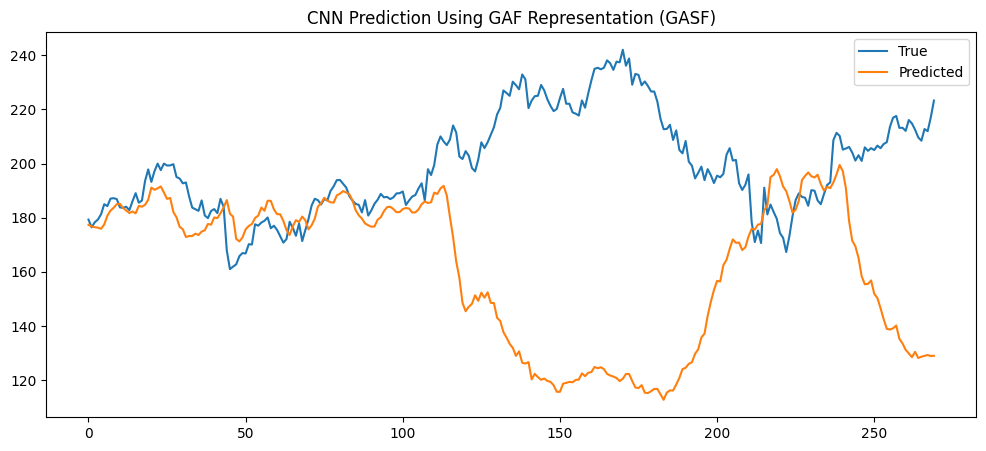

In [30]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD TIME SERIES
# =========================================================
TICKER = "AMZN"
START = "2020-01-01"
END = "2025-06-30"

data = yf.download(TICKER, start=START, end=END)
ts = data["Close"].dropna().values

print("Loaded series length:", len(ts))

# =========================================================
# 2. NORMALIZE LEVELS
# =========================================================
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts.reshape(-1, 1)).flatten()

# =========================================================
# 3. BUILD SUPERVISED DATASET
# =========================================================
WINDOW = 30

X_raw = []
y = []

for i in range(len(ts_scaled) - WINDOW):
    X_raw.append(ts_scaled[i:i + WINDOW])
    y.append(ts_scaled[i + WINDOW])

X_raw = np.array(X_raw)
y = np.array(y)

print("Raw sliding windows:", X_raw.shape)

# =========================================================
# 4. MANUAL GAF IMPLEMENTATION (GASF)
# =========================================================
def gaf_transform(series_batch):
    """
    series_batch: shape (n_samples, WINDOW)
    Output: GAF images (GASF): (n_samples, WINDOW, WINDOW)
    """
    eps = 1e-8
    X = np.clip(series_batch, -1 + eps, 1 - eps)

    phi = np.arccos(X)
    gaf = np.cos(phi[:, :, None] + phi[:, None, :])  # broadcast sum

    return gaf

# Generate GAF images
X_gaf = gaf_transform(X_raw)
X_gaf = X_gaf.reshape(X_gaf.shape[0], WINDOW, WINDOW, 1)

print("GAF images shape:", X_gaf.shape)

# =========================================================
# 5. TRAIN TEST SPLIT
# =========================================================
split = int(0.8 * len(X_gaf))
X_train, X_test = X_gaf[:split], X_gaf[split:]
y_train, y_test = y[:split], y[split:]

# =========================================================
# 6. CNN MODEL
# =========================================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(WINDOW, WINDOW, 1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)  # predict the next level (scaled)
])

model.compile(optimizer=Adam(0.001), loss="mse")

# =========================================================
# 7. TRAIN
# =========================================================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================================================
# 8. PREDICT (RESCALE)
# =========================================================
y_pred_scaled = model.predict(X_test).flatten()
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# =========================================================
# 9. PLOT RESULTS
# =========================================================
plt.figure(figsize=(12,5))
plt.plot(y_true, label="True")
plt.plot(y_pred, label="Predicted")
plt.title("CNN Prediction Using GAF Representation (GASF)")
plt.legend()
plt.show()



Step 3b

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 - 1s - 34ms/step - loss: 0.6643 - mae: 0.6232 - val_loss: 0.1628 - val_mae: 0.3161
Epoch 2/200
43/43 - 0s - 5ms/step - loss: 0.2786 - mae: 0.4100 - val_loss: 0.0809 - val_mae: 0.2234
Epoch 3/200
43/43 - 0s - 5ms/step - loss: 0.1314 - mae: 0.2822 - val_loss: 0.0389 - val_mae: 0.1559
Epoch 4/200
43/43 - 0s - 5ms/step - loss: 0.0657 - mae: 0.1946 - val_loss: 0.0223 - val_mae: 0.1136
Epoch 5/200
43/43 - 0s - 5ms/step - loss: 0.0436 - mae: 0.1563 - val_loss: 0.0122 - val_mae: 0.0863
Epoch 6/200
43/43 - 0s - 6ms/step - loss: 0.0276 - mae: 0.1228 - val_loss: 0.0086 - val_mae: 0.0717
Epoch 7/200
43/43 - 0s - 5ms/step - loss: 0.0170 - mae: 0.0976 - val_loss: 0.0063 - val_mae: 0.0604
Epoch 8/200
43/43 - 0s - 5ms/step - loss: 0.0143 - mae: 0.0866 - val_loss: 0.0047 - val_mae: 0.0509
Epoch 9/200
43/43 - 0s - 5ms/step - loss: 0.0114 - mae: 0.0775 - val_loss: 0.0037 - val_mae: 0.0445
Epoch 10/200
43/43 - 0s - 6ms/step - loss: 0.0102 - mae: 0.0709 - val_loss: 0.0033 - val_mae: 0.0419
Epoch 11/2

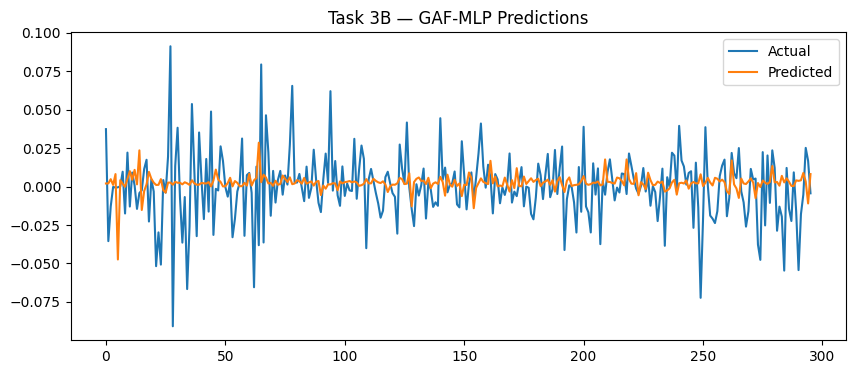

In [31]:
# ============================================================
# TASK 3B — GAF IMAGE TRANSFORMATION + MLP
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ------------------------------------------------------------
# 1. CUSTOM GAF TRANSFORM (REPLACES pyts)
# ------------------------------------------------------------
def gaf_transform(series, image_size):
    """Custom Gramian Angular Field (Summation)"""
    min_val = np.min(series)
    max_val = np.max(series)
    scaled = 2 * (series - min_val) / (max_val - min_val) - 1
    scaled = np.clip(scaled, -1, 1)
    phi = np.arccos(scaled)
    gaf = np.cos(phi[:, None] + phi[None, :])
    return gaf

# ------------------------------------------------------------
# 2. BUILD GAF DATASET
# ------------------------------------------------------------
WINDOW = 32
series_vals = stationary.values

X_gaf = []
y_gaf = []

for i in range(WINDOW, len(series_vals)):
    window = series_vals[i-WINDOW:i]
    img = gaf_transform(window, image_size=WINDOW)
    X_gaf.append(img)
    y_gaf.append(series_vals[i])

X_gaf = np.array(X_gaf)
y_gaf = np.array(y_gaf)

# Flatten images
X_flat = X_gaf.reshape((X_gaf.shape[0], -1))

# Split into train/val/test
train_end = int(0.7 * len(X_flat))
val_end   = int(0.85 * len(X_flat))

Xg_train, yg_train = X_flat[:train_end], y_gaf[:train_end]
Xg_val, yg_val     = X_flat[train_end:val_end], y_gaf[train_end:val_end]
Xg_test, yg_test   = X_flat[val_end:], y_gaf[val_end:]

scaler_gaf = StandardScaler()
Xg_train = scaler_gaf.fit_transform(Xg_train)
Xg_val   = scaler_gaf.transform(Xg_val)
Xg_test  = scaler_gaf.transform(Xg_test)

# ------------------------------------------------------------
# 3. MLP MODEL (same architecture as Task 2B)
# ------------------------------------------------------------
mlp_gaf = build_mlp(Xg_train.shape[1])

history_gaf = mlp_gaf.fit(
    Xg_train, yg_train,
    validation_data=(Xg_val, yg_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

# ------------------------------------------------------------
# 4. EVALUATE GAF-MLP
# ------------------------------------------------------------
print("\nTask 3B — GAF Model Performance:")
print("Test MSE:", mlp_gaf.evaluate(Xg_test, yg_test, verbose=0)[0])
print("Test MAE:", mlp_gaf.evaluate(Xg_test, yg_test, verbose=0)[1])

y_pred_gaf = mlp_gaf.predict(Xg_test).flatten()

plt.figure(figsize=(10,4))
plt.plot(yg_test, label="Actual")
plt.plot(y_pred_gaf, label="Predicted")
plt.title("Task 3B — GAF-MLP Predictions")
plt.legend()
plt.show()


**Step 3(c)**

Windowed dataset shape: (944, 32) (944,)
GAF shape: (944, 32, 32)
Split sizes -> Train: (660, 32, 32, 1) Val: (142, 32, 32, 1) Test: (142, 32, 32, 1)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,745 (2.07 MB)

 Trainable params: 543,553 (2.07 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,745 (2.07 MB)

 Trainable params: 543,553 (2.07 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/200
21/21 - 6s - 278ms/step - loss: 15.9022 - mae: 2.2442 - val_loss: 0.8797 - val_mae: 0.7379
Epoch 2/200
21/21 - 2s - 106ms/step - loss: 1.0651 - mae: 0.8175 - val_loss: 0.8129 - val_mae: 0.7021
Epoch 3/200
21/21 - 1s - 70ms/step - loss: 1.0082 - mae: 0.7892 - val_loss: 2.3157 - val_mae: 1.3391
Epoch 4/200
21/21 - 3s - 150ms/step - loss: 0.9595 - mae: 0.7792 - val_loss: 5.9535 - val_mae: 2.3113
Epoch 5/200
21/21 - 2s - 72ms/step - loss: 0.9594 - mae: 0.7789 - val_loss: 8.2429 - val_mae: 2.7545
Epoch 6/200
21/21 - 3s - 140ms/step - loss: 0.9187 - mae: 0.7518 - val_loss: 11.9967 - val_mae: 3.3631
Epoch 7/200
21/21 - 1s - 71ms/step - loss: 0.8836 - mae: 0.7378 - val_loss: 13.2714 - val_mae: 3.5438
Epoch 8/200
21/21 - 3s - 124ms/step - loss: 0.8776 - mae: 0.7391 - val_loss: 17.9337 - val_mae: 4.1450
Epoch 9/200
21/21 - 1s - 69ms/step - loss: 0.8439 - mae: 0.7253 - val_loss: 17.5511 - val_mae: 4.0926
Epoch 10/200
21/21 - 2s - 71ms/step - loss: 0.8389 - mae: 0.7247 - val_loss: 17.1

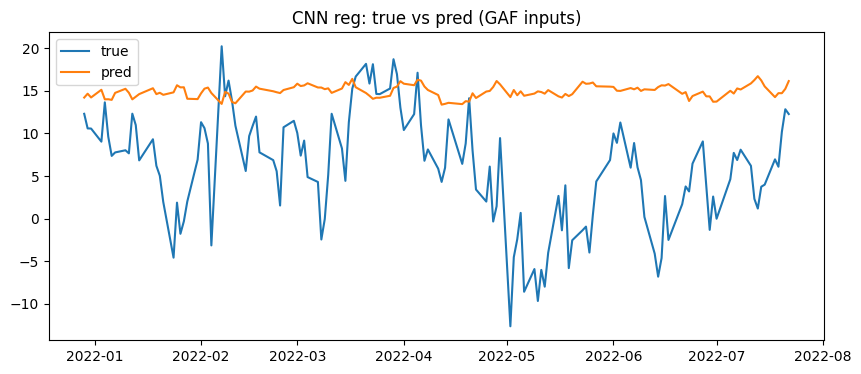

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Test (CNN bin) Acc: 0.211, AUC: 0.718
Confusion matrix:
 [[ 28   0]
 [112   2]]
              precision    recall  f1-score   support

           0       0.20      1.00      0.33        28
           1       1.00      0.02      0.03       114

    accuracy                           0.21       142
   macro avg       0.60      0.51      0.18       142
weighted avg       0.84      0.21      0.09       142



In [32]:
# Requirements:
# pip install pyts tensorflow scikit-learn matplotlib
# (Run pip from your notebook/terminal if needed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, roc_auc_score
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import math
import os

# ----------------------------
# SETTINGS (tune as needed)
# ----------------------------
LAGS = 32                # length of the past window (also becomes image size)
MAX_OBS = 2000           # ensure <= 2000 points
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 32
EPOCHS = 200
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ----------------------------
# Input: fd_series (pandas Series from Step 1)
# ----------------------------
# Example: fd_series = pandas Series indexed by date
series = fd_series.dropna().iloc[-MAX_OBS:].copy()
series.name = 'fd_close'

# ----------------------------
# 1) Build supervised dataset of lagged windows
# ----------------------------
def make_windows(series, window):
    # returns X_windows (n_samples, window), y (n_samples,)
    arr = series.values
    n = len(arr)
    X = []
    y = []
    idx = []
    for t in range(window, n):
        X.append(arr[t-window:t])   # past window: t-window ... t-1
        y.append(arr[t])            # target: value at t (fractionally differenced)
        idx.append(series.index[t])
    X = np.vstack(X)
    y = np.array(y)
    return X, y, np.array(idx)

X_win, y_reg, sample_idx = make_windows(series, LAGS)
print("Windowed dataset shape:", X_win.shape, y_reg.shape)

# ----------------------------
# 2) Create classification targets (optional)
# ----------------------------
# Binary direction
y_bin = (y_reg > 0).astype(int)

# Multi-class example (down/neutral/up) threshold at 25th abs-quantile
thr = np.quantile(np.abs(y_reg), 0.25)
def multi_lab(v, thr):
    if v > thr: return 2
    if v < -thr: return 0
    return 1
y_multi = np.array([multi_lab(v, thr) for v in y_reg])

# ----------------------------
# 3) Normalize windows to [-1, 1] for GAF
#    GAF expects values in [-1,1] when using standard pyts implementation
# ----------------------------
scaler_minmax = MinMaxScaler(feature_range=(-1, 1))
X_win_scaled = scaler_minmax.fit_transform(X_win)  # scale each column across samples
# NOTE: scaling across the dataset is fine because GAF mapping is per-sample polar conversion.
# Alternatively you could scale per-window; experiment if needed.

# ----------------------------
# 4) Convert windows to GAF images using pyts
#    We will create GASF (summation) images here; you can also create GADF ('difference')
# ----------------------------
image_size = LAGS  # GAF produces square image of size = window length
gaf = GramianAngularField(image_size=image_size, method='summation')  # GASF
X_gaf = gaf.transform(X_win_scaled)    # shape: (n_samples, image_size, image_size)
print("GAF shape:", X_gaf.shape)

# Add channel dimension for CNN
X_gaf = X_gaf[..., np.newaxis]   # shape -> (n_samples, H, W, 1)

# ----------------------------
# 5) Train/val/test split (time-ordered)
# ----------------------------
n = len(X_gaf)
n_test = int(math.ceil(TEST_SIZE * n))
n_val = int(math.ceil(VAL_SIZE * n))
n_train = n - n_val - n_test

X_train = X_gaf[:n_train];    y_train_reg = y_reg[:n_train];    y_train_bin = y_bin[:n_train];   y_train_multi = y_multi[:n_train]
X_val   = X_gaf[n_train:n_train+n_val]; y_val_reg = y_reg[n_train:n_train+n_val]; y_val_bin = y_bin[n_train:n_train+n_val]; y_val_multi = y_multi[n_train:n_train+n_val]
X_test  = X_gaf[n_train+n_val:]; y_test_reg = y_reg[n_train+n_val:]; y_test_bin = y_bin[n_train+n_val:]; y_test_multi = y_multi[n_train+n_val:]

print("Split sizes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Standardize regression target using training set
scaler_y = StandardScaler().fit(y_train_reg.reshape(-1,1))
y_train_reg_s = scaler_y.transform(y_train_reg.reshape(-1,1)).ravel()
y_val_reg_s   = scaler_y.transform(y_val_reg.reshape(-1,1)).ravel()
y_test_reg_s  = scaler_y.transform(y_test_reg.reshape(-1,1)).ravel()

# ----------------------------
# 6) Simple CNN builders (one for regression, one for classification)
# ----------------------------
def build_cnn(input_shape, regression=True, n_classes=2, base_filters=32, dropout=0.25, l2_reg=1e-4):
    inp = layers.Input(shape=input_shape)
    x = inp
    # Conv block 1
    x = layers.Conv2D(base_filters, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    # Conv block 2
    x = layers.Conv2D(base_filters*2, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    # Flatten + Dense
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)
    if regression:
        out = layers.Dense(1, activation='linear')(x)
        model = models.Model(inputs=inp, outputs=out)
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    else:
        if n_classes == 2:
            out = layers.Dense(1, activation='sigmoid')(x)
            model = models.Model(inputs=inp, outputs=out)
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        else:
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = models.Model(inputs=inp, outputs=out)
            model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

input_shape = X_train.shape[1:]   # (H, W, 1)

# Regression CNN
cnn_reg = build_cnn(input_shape, regression=True, l2_reg=1e-4, dropout=0.3)
cnn_reg.summary()

# Classification CNN (binary)
cnn_bin = build_cnn(input_shape, regression=False, n_classes=2, l2_reg=1e-4, dropout=0.3)
cnn_bin.summary()

# ----------------------------
# 7) Train with EarlyStopping
# ----------------------------
es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

hist_reg = cnn_reg.fit(X_train, y_train_reg_s,
                       validation_data=(X_val, y_val_reg_s),
                       epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=2)

# For classifier handle class imbalance
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_bin), y=y_train_bin)
class_weights = {i: cw[i] for i in range(len(cw))}

hist_bin = cnn_bin.fit(X_train, y_train_bin,
                       validation_data=(X_val, y_val_bin),
                       epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es],
                       class_weight=class_weights, verbose=2)

# ----------------------------
# 8) Evaluate - regression
# ----------------------------
y_pred_reg_s = cnn_reg.predict(X_test).ravel()
y_pred_reg = scaler_y.inverse_transform(y_pred_reg_s.reshape(-1,1)).ravel()

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"Test (CNN reg) RMSE: {rmse:.6g}, MAE: {mae:.6g}")

# Plot sample true vs pred
plt.figure(figsize=(10,4))
plt.plot(sample_idx[n_train+n_val:][-200:], y_test_reg[-200:], label='true')
plt.plot(sample_idx[n_train+n_val:][-200:], y_pred_reg[-200:], label='pred')
plt.legend(); plt.title('CNN reg: true vs pred (GAF inputs)')
plt.show()

# ----------------------------
# 9) Evaluate - binary classification
# ----------------------------
y_prob = cnn_bin.predict(X_test).ravel()
y_pred_bin = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test_bin, y_pred_bin)
try:
    auc = roc_auc_score(y_test_bin, y_prob)
except:
    auc = np.nan
print(f"Test (CNN bin) Acc: {acc:.3f}, AUC: {auc:.3f}")

# Confusion matrix (quick)
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion matrix:\n", confusion_matrix(y_test_bin, y_pred_bin))
print(classification_report(y_test_bin, y_pred_bin))

# ----------------------------
# 10) (Optional) try GADF as well:
# ----------------------------
# gaf_diff = GramianAngularField(image_size=image_size, method='difference')
# X_gadf = gaf_diff.transform(X_win_scaled)[..., np.newaxis]
# (Then repeat training / compare)

**FootNote**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.